In [1]:
import pandas as pd
import requests
import json
from scipy.stats import norm
import matplotlib.pyplot as plt


In [2]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.facecolor': '#020617',
    'axes.facecolor': '#0d1520',
    'axes.edgecolor': '#1a2535',
    'axes.labelcolor': '#e5e7eb',
    'xtick.color': '#e5e7eb',
    'ytick.color': '#e5e7eb',
    'text.color': '#e5e7eb',
    'grid.color': '#1a2535',
    'grid.alpha': 0.5,
    'legend.facecolor': '#0d1520',
    'legend.edgecolor': '#1a2535',
})

In [3]:
maps = json.loads(requests.get("https://api.csapi.de/maps").text)

In [4]:
active_maps = maps[1:8]
active_maps

[{'id': 1, 'name': 'Anubis'},
 {'id': 2, 'name': 'Overpass'},
 {'id': 3, 'name': 'Ancient'},
 {'id': 4, 'name': 'Dust2'},
 {'id': 5, 'name': 'Nuke'},
 {'id': 6, 'name': 'Mirage'},
 {'id': 7, 'name': 'Inferno'}]

In [5]:
def get_map_data(url, active_maps):

    df = pd.DataFrame()
    for m in active_maps:
        
        parsed = json.loads(requests.get(f"{url}?limit=100000&mapid={m['id']}").text)
        df_map = pd.DataFrame(parsed)
        df_map['map_id'] = m['id']
        
        df = pd.concat([df,df_map])

    return df
    


In [6]:

df = get_map_data("https://api.csapi.de/players/stats", active_maps)
df

,id,name,team_id,team_name,k,d,swing,adr,kast,rating,map_id
0,21159,bobeksde,11737,EYEBALLERS,27,24,6.85,90.3,88.6,1.51,1
1,20879,maxster,11737,EYEBALLERS,34,23,1.55,90.4,74.3,1.37,1
2,22914,dex,11737,EYEBALLERS,23,26,-1.24,65.4,68.6,0.95,1
3,3849,jw,11737,EYEBALLERS,22,23,-4.08,59.0,65.7,0.84,1
4,21012,ro1f,11737,EYEBALLERS,12,26,-6.62,55.7,65.7,0.63,1
...,...,...,...,...,...,...,...,...,...,...,...
5381,20207,raijin,10459,ARCRED,20,18,-0.73,100.5,87.0,1.30,7
5382,20402,synyx,10459,ARCRED,15,14,2.80,74.0,82.6,1.18,7
5383,18671,get-jeka,10459,ARCRED,12,15,-4.33,56.0,82.6,0.88,7
5384,19703,ryujin,10459,ARCRED,10,11,-2.33,39.7,65.2,0.86,7


/home/gwent/anaconda3/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:709: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/home/gwent/anaconda3/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


Sigma intervals
beta: 0.7175215909349628  1.4414494588707834
norm: 0.709805780158597  1.4473195244717845
mean: 1.0785626523151908   std: 0.3687568721565938


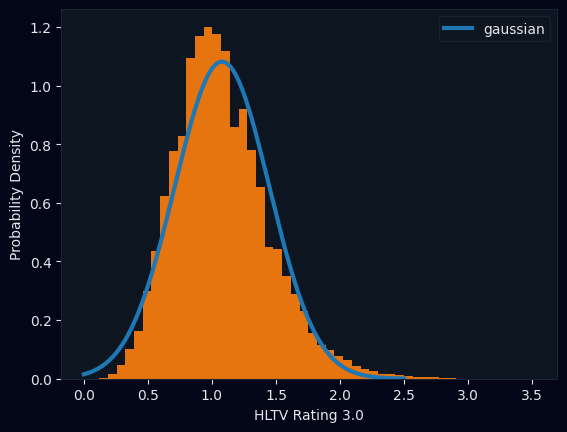

In [12]:
import math
import numpy as np
import scipy.stats as stats

ratings = df['rating']

def plot_rating_distribution(r, x_from = -2.5, x_to=2.5, n_bins=50,x_label = 'HLTV Rating 3.0' ,name='out.png'):

    mu = r.mean()
    variance = r.std()
    sigma = math.sqrt(variance)
    x = np.linspace(x_from, x_to, 500)
    params = stats.beta.fit(r)

    params_norm = stats.norm.fit(r)
    params_gamma = stats.gamma.fit(r)

    # plt.plot(x, stats.beta.pdf(x,*params), label='beta')
    plt.plot(x, stats.norm.pdf(x,*params_norm), label='gaussian', linewidth=3)
    # plt.plot(x, stats.gamma.pdf(x,*params_gamma), label='gamma')
    plt.xlabel(x_label)
    plt.ylabel(r"Probability Density")

    plt.legend()


    # print(f"EV: {scale * (a/(a+b)) + l}")

    lower_1sigma = stats.beta.ppf(0.15865, *params)
    upper_1sigma = stats.beta.ppf(0.84135, *params)

    print("Sigma intervals")
    
    print(f"beta: {lower_1sigma}  {upper_1sigma}")
    print(f"norm: {r.mean() - r.std()}  {r.mean() + r.std()}")


    plt.hist(r, bins=n_bins, density=True, alpha=0.9)
    print(f"mean: {r.mean()}   std: {r.std()}")
    plt.savefig(name)

plot_rating_distribution(ratings, 0,2.5,50, name = "rating-distribution.svg")

/home/gwent/anaconda3/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:709: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/home/gwent/anaconda3/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


Sigma intervals
beta: -0.3370119160427407  0.36816265703401996
norm: -0.34020565451319296  0.37118713584612806
mean: 0.015490740666467526   std: 0.3556963951796605


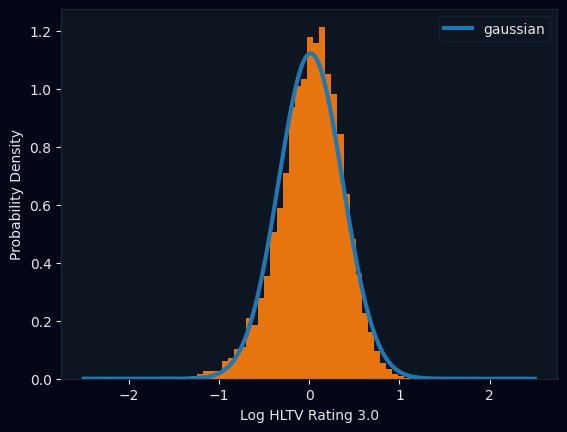

In [13]:

mod_ratings = np.log(ratings)


plot_rating_distribution(mod_ratings, x_label = 'Log HLTV Rating 3.0', name="log-rating-distribution.svg")

In [10]:
mu_pop = ratings.mean()
sigma_pop = ratings.std()

In [9]:
df_wins = get_map_data("https://api.csapi.de/players/stats/win", active_maps)
df_wins

,id,name,team_id,team_name,k,d,swing,adr,kast,rating,map_id
0,7322,apex,9565,Vitality,18,28,-4.14,73.8,62.9,0.79,1
1,11816,ropz,9565,Vitality,24,20,1.66,74.4,80.0,1.21,1
2,11893,zywoo,9565,Vitality,24,21,1.29,62.1,74.3,1.10,1
3,16693,flamez,9565,Vitality,30,25,0.77,84.8,80.0,1.26,1
4,18462,mezii,9565,Vitality,26,25,3.97,81.5,71.4,1.21,1
...,...,...,...,...,...,...,...,...,...,...,...
2566,7443,twist,12474,Alliance,12,15,0.65,62.3,78.3,1.03,7
2567,16487,eraa,12474,Alliance,23,13,6.15,93.0,87.0,1.56,7
2568,22760,upe,12474,Alliance,8,14,-4.08,51.4,65.2,0.64,7
2569,22860,avid,12474,Alliance,14,15,1.15,63.8,69.6,1.06,7


In [10]:
df_loses = get_map_data("https://api.csapi.de/players/stats/lose", active_maps)
df_loses

,id,name,team_id,team_name,k,d,swing,adr,kast,rating,map_id
0,3849,jw,11737,EYEBALLERS,22,23,-4.08,59.0,65.7,0.84,1
1,20879,maxster,11737,EYEBALLERS,34,23,1.55,90.4,74.3,1.37,1
2,21012,ro1f,11737,EYEBALLERS,12,26,-6.62,55.7,65.7,0.63,1
3,21159,bobeksde,11737,EYEBALLERS,27,24,6.85,90.3,88.6,1.51,1
4,22914,dex,11737,EYEBALLERS,23,26,-1.24,65.4,68.6,0.95,1
...,...,...,...,...,...,...,...,...,...,...,...
2565,18447,dssj,10459,ARCRED,12,14,-0.79,51.7,60.9,0.77,7
2566,18671,get-jeka,10459,ARCRED,12,15,-4.33,56.0,82.6,0.88,7
2567,19703,ryujin,10459,ARCRED,10,11,-2.33,39.7,65.2,0.86,7
2568,20207,raijin,10459,ARCRED,20,18,-0.73,100.5,87.0,1.30,7


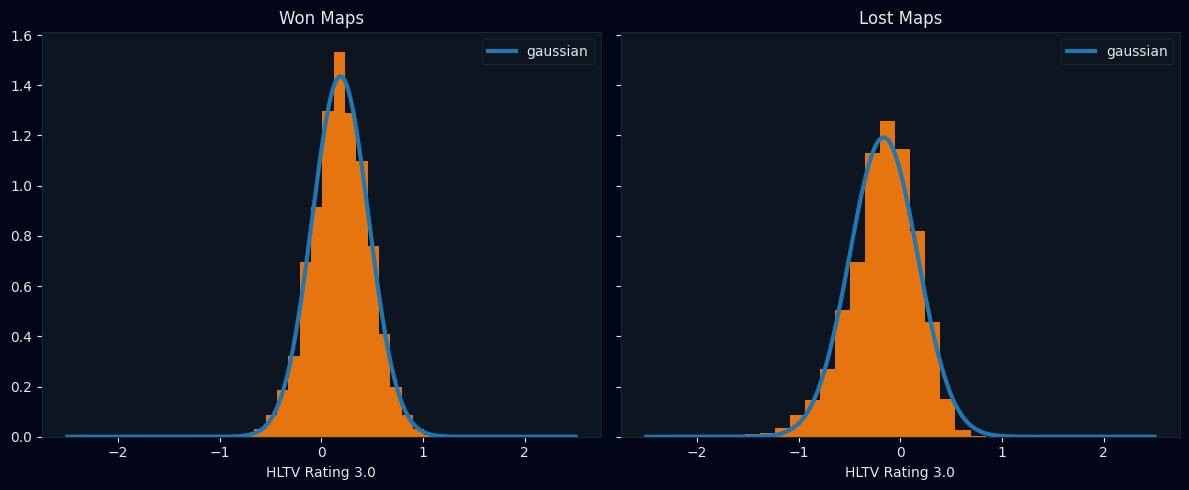

In [14]:

def plot_rating_distribution_outcome(r_won, r_lost, x_from=-2.5, x_to=2.5, n_bins=20, x_label = "HLTV Rating 3.0", name = None):
    x = np.linspace(x_from, x_to, 500)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    for ax, data, label in zip(axes, [r_won, r_lost], ["Won Maps", "Lost Maps"]):
        params_norm = stats.norm.fit(data)
        ax.plot(x, stats.norm.pdf(x, *params_norm), label='gaussian', linewidth=3)

        ax.hist(data, bins=n_bins, density=True, alpha=0.9)
        ax.set_title(label)
        ax.set_xlabel(x_label)
        ax.legend()

    plt.tight_layout()
    if name:
        plt.savefig(name)

    plt.show()


plot_rating_distribution_outcome(np.log(df_wins['rating']), np.log(df_loses['rating']), name ="won-lost-distribution.svg")

w0nderful 29 28


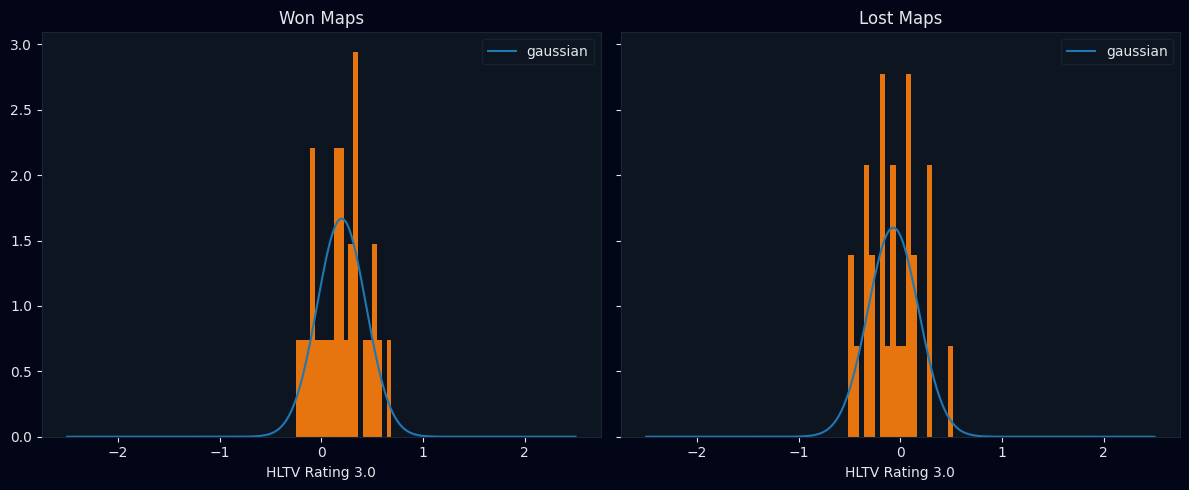

ropz 56 19


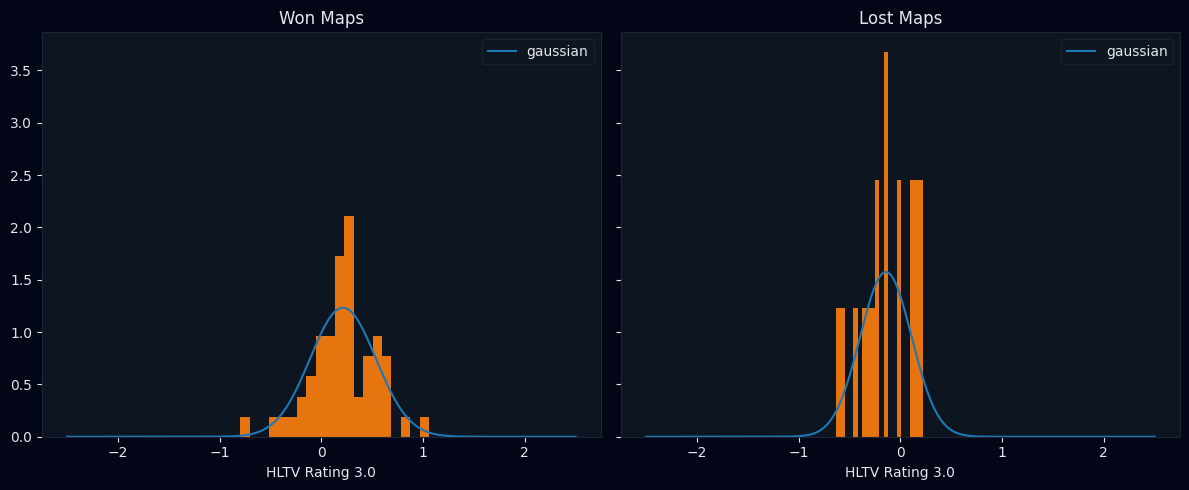

flamez 56 19


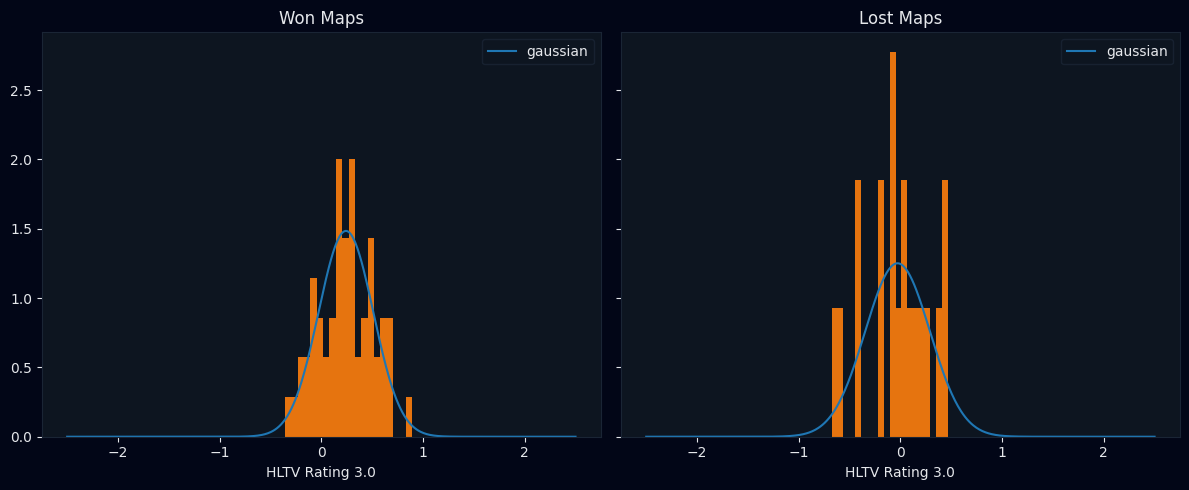

zywoo 56 19


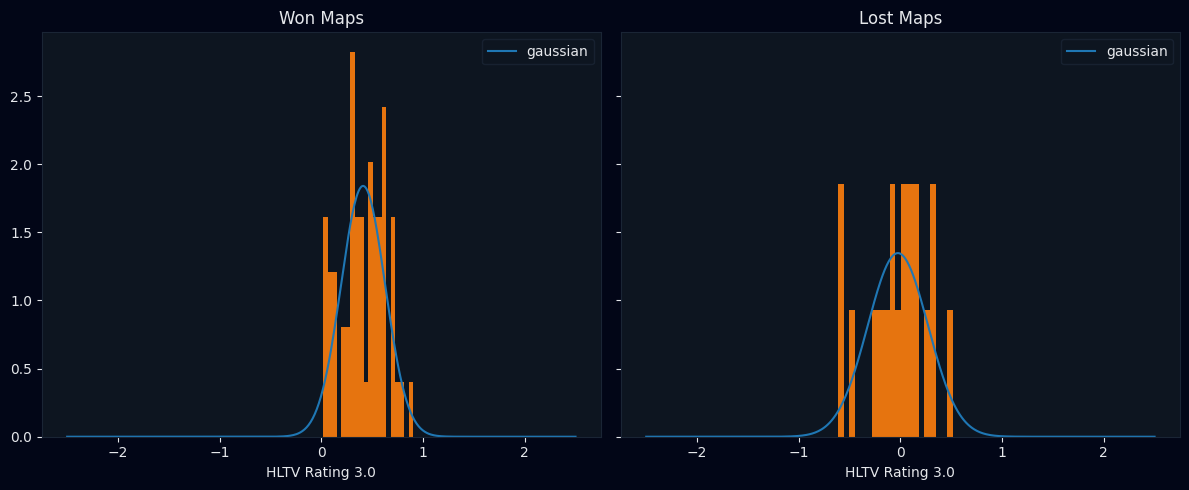

mezii 56 19


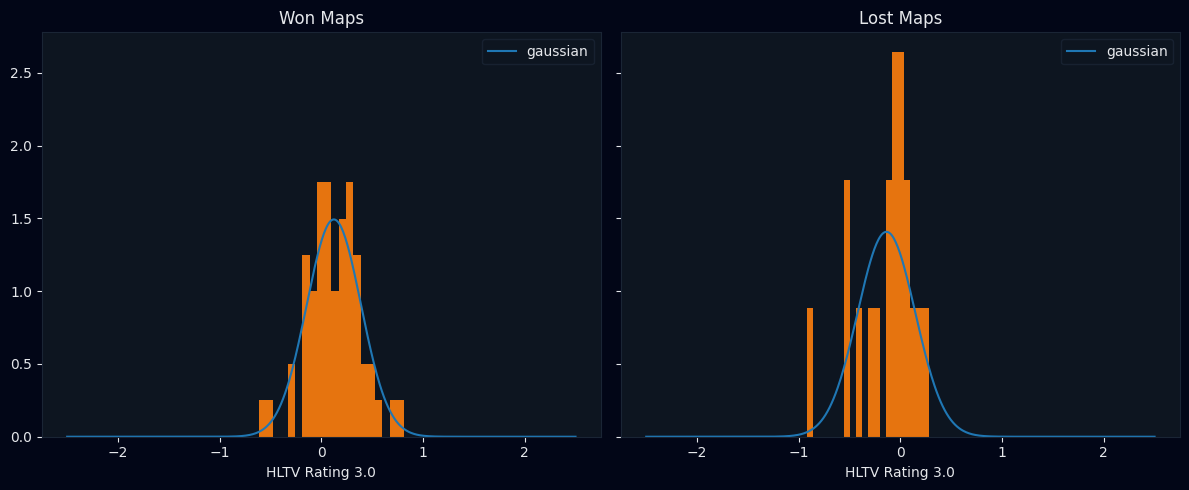

apex 56 19


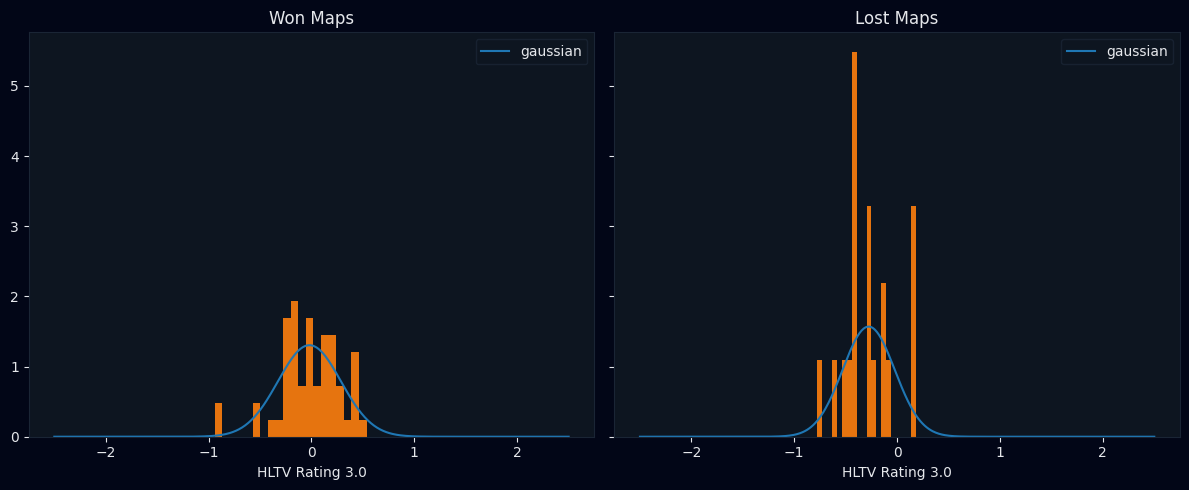

nota 43 26


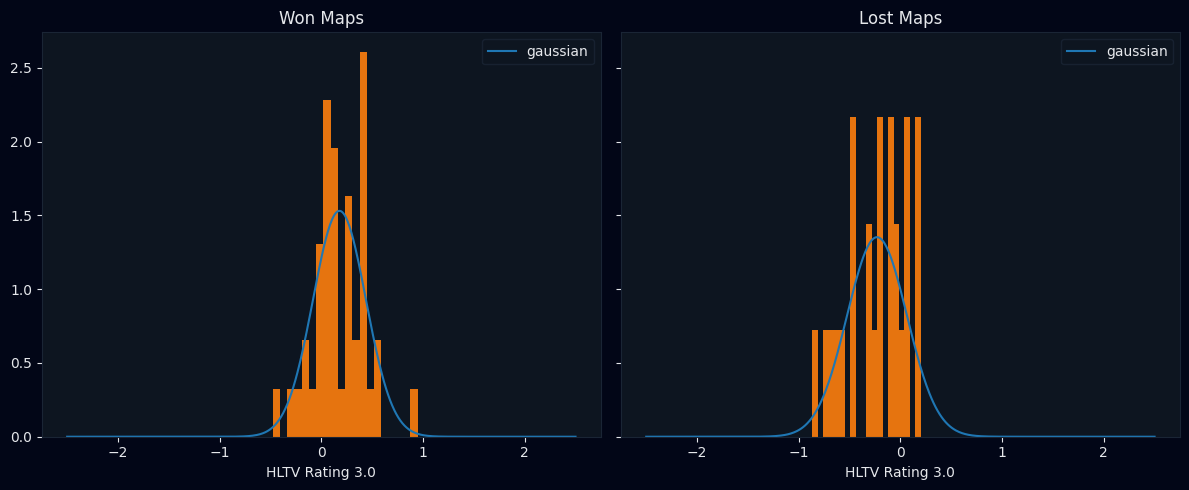

kyousuke 35 20


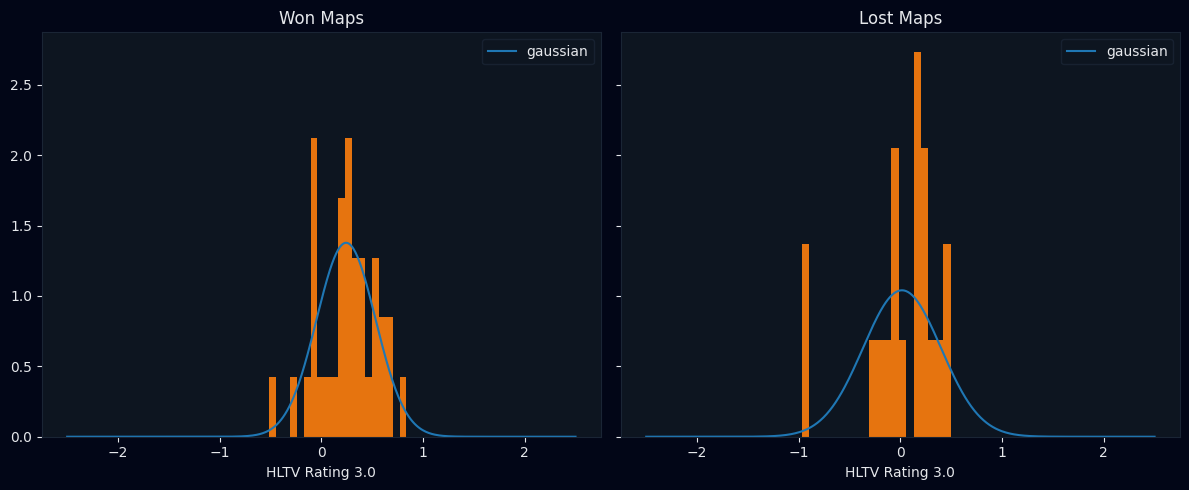

m0nesy 39 24


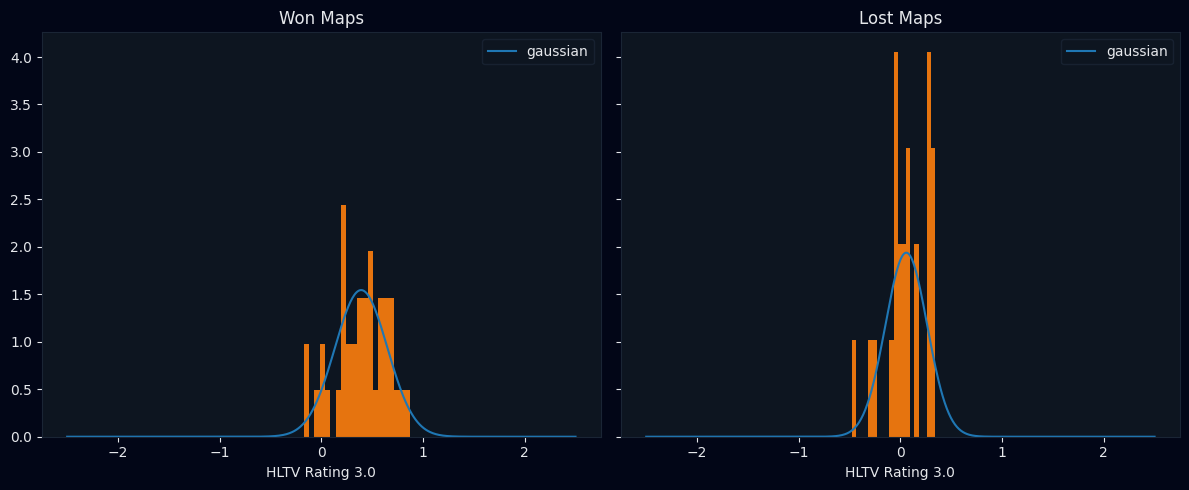

niko 39 24


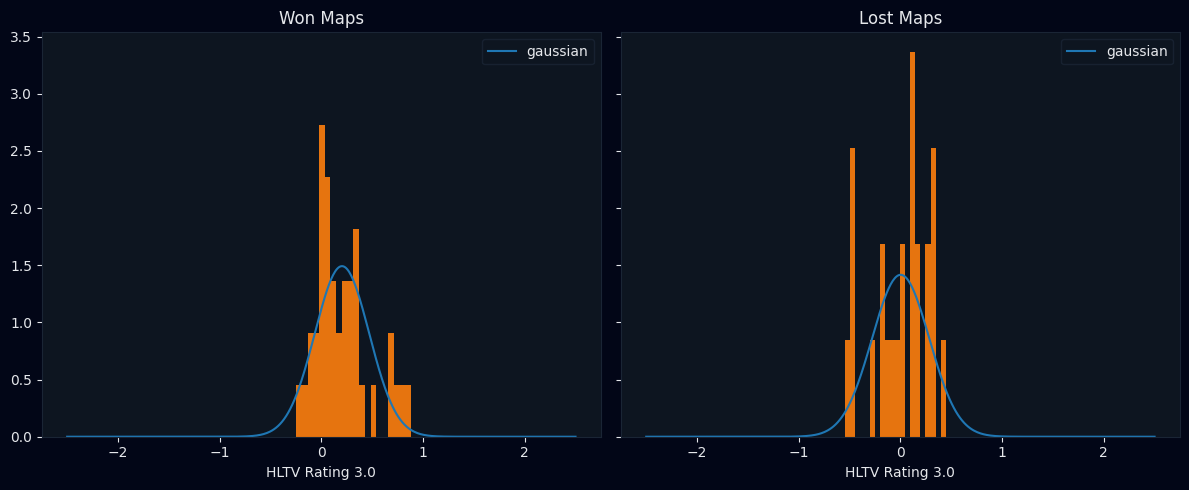

maj3r 36 32


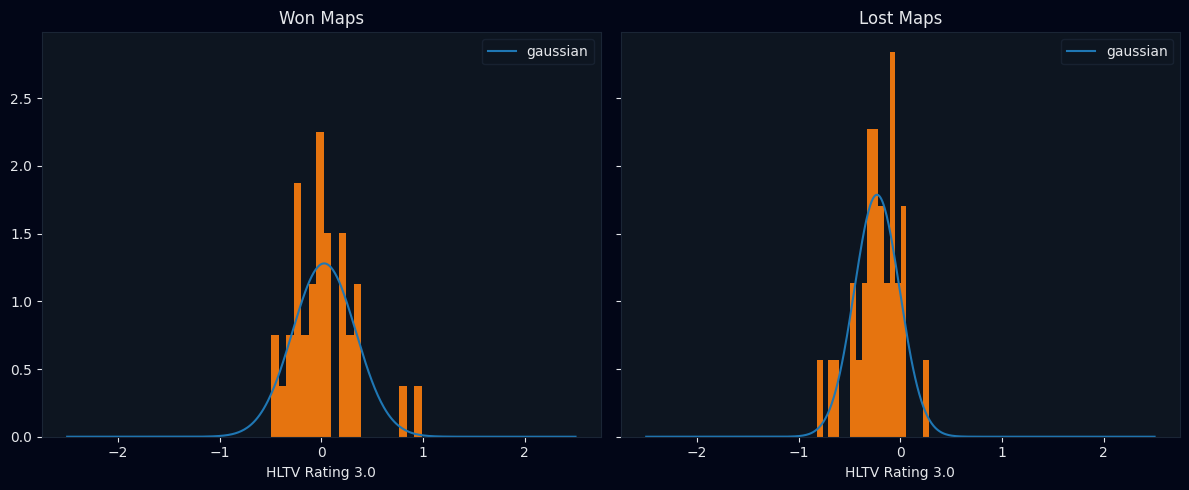

In [14]:
import warnings
warnings.filterwarnings("ignore")

players = [
    'w0nderful',
    'ropz',
    'flamez',
    'zywoo',
    'mezii',
    'apex',
    'nota',
    'kyousuke',
    'm0nesy',
    'niko',
    'maj3r'
    ]


for p in players:
    df_p_wins = df_wins[df_wins['name'] == p]
    df_p_loses = df_loses[df_loses['name'] == p]
    print(p, len(df_p_wins),len(df_p_loses))
    plot_rating_distribution_outcome(np.log(df_p_wins['rating']), np.log(df_p_loses['rating']))
    plt.show()
    # print(f"mean: {mean:.2f}", f"{p_ratings.mean():.2f}", f"Points mean: {(p_ratings.mean()-1)*50:.2f}")

In [15]:
wins_group = df_wins.groupby(by=['map_id', 'id'])

wins_group

In [16]:
def shrunk_mu(mu_player, mu_pop, n, n_prior=20):
    return (n * mu_player + n_prior * mu_pop)/(n + n_prior)

In [17]:
PLAYERS = [
    'w0nderful',
    'ropz',
    'flamez',
    'zywoo',
    'mezii',
    'apex',
    'nota',
    'kyousuke',
    'm0nesy',
    'niko',
    'maj3r',
    'blitz'
    ]

MU_POP_WIN = np.log(df_wins['rating']).mean() 
MU_POP_LOSE = np.log(df_loses['rating']).mean() 

In [18]:
print(MU_POP_WIN)
print(MU_POP_LOSE)

0.1870946813559815
-0.1653107572190407


In [19]:
for p in players:
    df_win_p = np.log(df_wins[df_wins['name'] == p]['rating'])
    df_lose_p = np.log(df_loses[df_loses['name'] == p]['rating'])
    mu_win = df_win_p.mean()
    mu_lose = df_lose_p.mean()

    n_lose = len(df_lose_p)
    n_win = len(df_win_p)

    mu_win_shrunk = shrunk_mu(mu_win, MU_POP_WIN, n_win)
    mu_lose_shrunk = shrunk_mu(mu_lose, MU_POP_LOSE, n_lose)
    print(p)
    print('Log Ratings')
    print(f"N(win): {n_win}  N(lose): {n_lose}" )
    print(f"mu(win): {mu_win:.2f}  mu(shrunk): {mu_win_shrunk:.2f}")
    print(f"mu(lose): {mu_lose:.2f}  mu(shrunk): {mu_lose_shrunk:.2f}")
    print("Ratings")
    print(f"mu(win): {np.exp(mu_win):.2f}  mu(shrunk): {np.exp(mu_win_shrunk):.2f}")
    print(f"mu(lose): {np.exp(mu_lose):.2f}  mu(shrunk): {np.exp(mu_lose_shrunk):.2f}")


w0nderful
Log Ratings
N(win): 29  N(lose): 28
mu(win): 0.20  mu(shrunk): 0.19
mu(lose): -0.07  mu(shrunk): -0.11
Ratings
mu(win): 1.22  mu(shrunk): 1.21
mu(lose): 0.93  mu(shrunk): 0.90
ropz
Log Ratings
N(win): 56  N(lose): 19
mu(win): 0.21  mu(shrunk): 0.21
mu(lose): -0.14  mu(shrunk): -0.15
Ratings
mu(win): 1.24  mu(shrunk): 1.23
mu(lose): 0.87  mu(shrunk): 0.86
flamez
Log Ratings
N(win): 56  N(lose): 19
mu(win): 0.24  mu(shrunk): 0.23
mu(lose): -0.03  mu(shrunk): -0.10
Ratings
mu(win): 1.27  mu(shrunk): 1.26
mu(lose): 0.97  mu(shrunk): 0.91
zywoo
Log Ratings
N(win): 56  N(lose): 19
mu(win): 0.41  mu(shrunk): 0.35
mu(lose): -0.02  mu(shrunk): -0.10
Ratings
mu(win): 1.51  mu(shrunk): 1.42
mu(lose): 0.98  mu(shrunk): 0.91
mezii
Log Ratings
N(win): 56  N(lose): 19
mu(win): 0.12  mu(shrunk): 0.14
mu(lose): -0.14  mu(shrunk): -0.15
Ratings
mu(win): 1.13  mu(shrunk): 1.15
mu(lose): 0.87  mu(shrunk): 0.86
apex
Log Ratings
N(win): 56  N(lose): 19
mu(win): -0.02  mu(shrunk): 0.03
mu(lose): -0

In [20]:
apex_df_win = df_wins[df_wins['name']=='apex']
apex_df_win['win'] = 1
apex_df_win

,id,name,team_id,team_name,k,d,swing,adr,kast,rating,map_id,win
0,7322,apex,9565,Vitality,18,28,-4.14,73.8,62.9,0.79,1,1
80,7322,apex,9565,Vitality,9,10,-2.90,65.1,82.4,0.95,1,1
410,7322,apex,9565,Vitality,21,13,4.38,99.8,85.7,1.54,1,1
0,7322,apex,9565,Vitality,11,13,-2.08,57.7,66.7,0.85,2,1
60,7322,apex,9565,Vitality,16,13,1.31,81.6,71.4,1.13,2,1
215,7322,apex,9565,Vitality,11,8,6.18,77.9,86.7,1.57,2,1
660,7322,apex,9565,Vitality,14,18,-4.32,54.6,72.4,0.78,2,1
690,7322,apex,9565,Vitality,10,11,3.37,83.4,86.7,1.15,2,1
1525,7322,apex,9565,Vitality,14,8,5.67,82.9,88.9,1.52,2,1
1635,7322,apex,9565,Vitality,18,13,4.78,114.2,85.0,1.56,2,1


In [21]:
apex_df_lose = df_loses[df_loses['name']=='apex']
apex_df_lose['win'] = 0
apex_df_lose

,id,name,team_id,team_name,k,d,swing,adr,kast,rating,map_id,win
765,7322,apex,9565,Vitality,19,17,-0.08,75.5,62.5,1.15,2,0
955,7322,apex,9565,Vitality,6,15,-1.31,45.5,59.1,0.65,2,0
1295,7322,apex,9565,Vitality,14,17,-3.29,63.8,58.3,0.75,3,0
1105,7322,apex,9565,Vitality,8,14,-3.28,43.0,66.7,0.67,4,0
420,7322,apex,9565,Vitality,7,14,-6.78,56.5,57.9,0.59,5,0
585,7322,apex,9565,Vitality,6,14,0.11,45.1,65.0,0.77,5,0
1030,7322,apex,9565,Vitality,11,12,-0.30,64.5,55.0,0.88,5,0
1125,7322,apex,9565,Vitality,11,19,-3.79,56.3,70.8,0.67,5,0
1165,7322,apex,9565,Vitality,5,15,-5.07,28.7,41.2,0.46,5,0
1395,7322,apex,9565,Vitality,16,23,-2.89,73.1,70.0,0.89,5,0


In [22]:
df_apex = pd.concat([apex_df_win, apex_df_lose])

df_apex

,id,name,team_id,team_name,k,d,swing,adr,kast,rating,map_id,win
0,7322,apex,9565,Vitality,18,28,-4.14,73.8,62.9,0.79,1,1
80,7322,apex,9565,Vitality,9,10,-2.90,65.1,82.4,0.95,1,1
410,7322,apex,9565,Vitality,21,13,4.38,99.8,85.7,1.54,1,1
0,7322,apex,9565,Vitality,11,13,-2.08,57.7,66.7,0.85,2,1
60,7322,apex,9565,Vitality,16,13,1.31,81.6,71.4,1.13,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
950,7322,apex,9565,Vitality,10,14,-5.14,74.7,44.4,0.75,7,0
1065,7322,apex,9565,Vitality,5,18,-6.46,50.5,56.5,0.54,7,0
1265,7322,apex,9565,Vitality,19,25,-2.66,58.8,78.0,0.81,7,0
1870,7322,apex,9565,Vitality,10,17,-4.70,42.4,60.9,0.67,7,0


In [23]:
groupby_apex = df_apex.groupby(by=['map_id', 'team_id', 'id'])

groupby_apex = groupby_apex.agg({'win': ['sum', 'count']}).reset_index()



In [24]:
groupby_apex['winrate'] = groupby_apex['win']['sum']/groupby_apex['win']['count']

groupby_apex['popularity'] = groupby_apex['win']['count']/groupby_apex['win']['count'].sum()
groupby_apex['confidence'] = groupby_apex['win']['count']/(groupby_apex['win']['count'].sum() + 10) 

groupby_apex['winrate_smoothed'] = (groupby_apex['win']['sum']+ 15)/(groupby_apex['win']['count'] + (2* 15)) 

groupby_apex['strength'] = 400 * np.log(groupby_apex['winrate_smoothed']/(1-groupby_apex['winrate_smoothed']))


groupby_apex

map_id team_id    id win         winrate popularity confidence  \
                       sum count                                   
0      1    9565  7322   3     3  1.000000   0.040000   0.035294   
1      2    9565  7322  10    12  0.833333   0.160000   0.141176   
2      3    9565  7322   1     2  0.500000   0.026667   0.023529   
3      4    9565  7322  14    15  0.933333   0.200000   0.176471   
4      5    9565  7322   8    14  0.571429   0.186667   0.164706   
5      6    9565  7322   8    11  0.727273   0.146667   0.129412   
6      7    9565  7322  12    18  0.666667   0.240000   0.211765   

  winrate_smoothed    strength  
                                
0         0.545455   72.928623  
1         0.595238  154.264992  
2         0.500000    0.000000  
3         0.644444  237.882843  
4         0.522727   36.388711  
5         0.560976   98.048983  
6         0.562500  100.525771

In [25]:
def calc_strength(df_p,c=15,K=400):
    groupby_p = df_p.groupby(by=['map_id', 'team_id', 'id'])
    groupby_p = groupby_p.agg({'win': ['sum', 'count']}).reset_index()

    groupby_p['winrate'] = groupby_p['win']['sum']/groupby_p['win']['count']


    groupby_p['winrate_smoothed'] = (groupby_p['win']['sum']+ c)/(groupby_p['win']['count'] + (2* c)) 

    groupby_p['strength'] = K * np.log10(groupby_p['winrate_smoothed']/(1-groupby_p['winrate_smoothed']))


    return groupby_p

def bradley_terry(R_i, R_j, base=10, K=400):
    return 1/(1+base**((R_j - R_i)/K))

In [26]:
bradley_terry(127.381492, 154.264992)

0.46138856079729046

In [27]:
PLAYERS = ['apex', 'blitz']

df_wins['win'] = 1
df_loses['win'] = 0

df_stats = pd.concat([df_wins, df_loses])

for p in PLAYERS:
    print(p)
    gb = calc_strength(df_stats[df_stats['name'] == p])
    print(gb)


apex
  map_id team_id    id win         winrate winrate_smoothed    strength
                       sum count                                       
0      1    9565  7322   3     3  1.000000         0.545455   31.672498
1      2    9565  7322  10    12  0.833333         0.595238   66.996435
2      3    9565  7322   1     2  0.500000         0.500000    0.000000
3      4    9565  7322  14    15  0.933333         0.644444  103.311206
4      5    9565  7322   8    14  0.571429         0.522727   15.803417
5      6    9565  7322   8    11  0.727273         0.560976   42.582132
6      7    9565  7322  12    18  0.666667         0.562500   43.657788
blitz
  map_id team_id     id win         winrate winrate_smoothed   strength
                        sum count                                      
0      2    6248  20194   1     3  0.333333         0.484848 -10.531575
1      3    6248  20194   6    10  0.600000         0.525000  17.386278
2      4    6248  20194   4    12  0.333333         0

In [28]:
df_wins['win'] = 1
df_loses['win'] = 0

df_stats = pd.concat([df_wins, df_loses])

df_vit = calc_strength(df_stats[df_stats['name'] == 'apex'])[['map_id', 'strength']].reset_index()

df_mon = calc_strength(df_stats[df_stats['name'] == 'blitz'])[['map_id', 'strength']].reset_index()

p_vit = pd.DataFrame(columns=['map_id', 'p_win'])

print("Vitality - MongolZ")
for i,map_id in df_vit['map_id'].items():
    map_row = sorted([m['name'] if m['id'] == map_id else "" for m in active_maps])
    print(map_row[-1])
    row_vit = df_vit[df_vit['map_id'] == map_id]
    row_mon = df_mon[df_mon['map_id'] == map_id]

    vit_s = row_vit['strength'].item() if not row_vit['strength'].empty else -400

    mon_s = row_mon['strength'].item() if not row_mon['strength'].empty else -400


    p_win = bradley_terry(vit_s, mon_s)

    p_vit.loc[i] = [map_id, p_win]


    print(f"BT Winrate: {p_win*100:.2f}% - {(1-p_win)*100:.2f}%")
    print()

    #print(f"GT Winrate: {(4/6)*100:.2f}")

Vitality - MongolZ
Anubis
BT Winrate: 92.31% - 7.69%

Overpass
BT Winrate: 60.98% - 39.02%

Ancient
BT Winrate: 47.50% - 52.50%

Dust2
BT Winrate: 68.69% - 31.31%

Nuke
BT Winrate: 52.27% - 47.73%

Mirage
BT Winrate: 55.00% - 45.00%

Inferno
BT Winrate: 60.00% - 40.00%



In [29]:
import scipy.special as special


p_vit['win_softmax'] = special.softmax(p_vit['p_win']/0.05)

p_vit

,map_id,p_win,win_softmax
0,1.0,0.923077,0.986792
1,2.0,0.609756,0.001874
2,3.0,0.475000,0.000127
3,4.0,0.686921,0.008770
4,5.0,0.522727,0.000329
5,6.0,0.550000,0.000567
6,7.0,0.600000,0.001542


In [30]:
def simulate_bo3(p,tau= 0.05):

    picks = pd.DataFrame()
    p['win_sm'] = special.softmax(p['p_win']/tau)
    p['lose_sm'] = special.softmax((1-p['p_win'])/tau)


    # ban phase 1
    ban_t1 = np.random.choice(p['map_id'], p=p['lose_sm'])
    p.drop(p[p['map_id'] == ban_t1].index, inplace=True)

    p['win_sm'] = special.softmax(p['p_win']/tau)
    p['lose_sm'] = special.softmax((1-p['p_win'])/tau)


    ban_t2 = np.random.choice(p['map_id'], p=p['win_sm'])
    p.drop(p[p['map_id'] == ban_t2].index, inplace=True)

    p['win_sm'] = special.softmax(p['p_win']/tau)
    p['lose_sm'] = special.softmax((1-p['p_win'])/tau)

    # Pick Phase 1

    pick_t1 = np.random.choice(p['map_id'], p=p['win_sm'])
    picks = pd.concat([picks, p[p['map_id'] == pick_t1]])
    p.drop(p[p['map_id'] == pick_t1].index, inplace=True)


    p['win_sm'] = special.softmax(p['p_win']/tau)
    p['lose_sm'] = special.softmax((1-p['p_win'])/tau)


    pick_t2 = np.random.choice(p['map_id'], p=p['lose_sm'])
    picks = pd.concat([picks, p[p['map_id'] == pick_t2]])
    p.drop(p[p['map_id'] == pick_t2].index, inplace=True)

    p['win_sm'] = special.softmax(p['p_win']/tau)
    p['lose_sm'] = special.softmax((1-p['p_win'])/tau)

    # Ban Phase 2
    ban_t1 = np.random.choice(p['map_id'], p=p['lose_sm'])
    p.drop(p[p['map_id'] == ban_t1].index, inplace=True)

    p['win_sm'] = special.softmax(p['p_win']/tau)
    p['lose_sm'] = special.softmax((1-p['p_win'])/tau)


    ban_t2 = np.random.choice(p['map_id'], p=p['win_sm'])
    p.drop(p[p['map_id'] == ban_t2].index, inplace=True)

    p['win_sm'] = special.softmax(p['p_win']/tau)
    p['lose_sm'] = special.softmax((1-p['p_win'])/tau)

    # Decider

    picks = pd.concat([picks, p])

    return picks



In [31]:
def simulate_bo3_fast(p_win_array, tau=0.05):
    p = p_win_array.copy()
    picks = []

    def softmax(x):
        e = np.exp(x / tau)
        return e / e.sum()

    def do_ban(worst=True):
        probs = softmax(1 - p) if worst else softmax(p)
        idx = np.random.choice(len(p), p=probs)
        return idx

    def do_pick(best=True):
        probs = softmax(p) if best else softmax(1 - p)
        idx = np.random.choice(len(p), p=probs)
        return idx

    def remove(idx):
        nonlocal p
        p = np.delete(p, idx)

    remove(do_ban(worst=True))
    remove(do_ban(worst=False))
    picks.append(p[do_pick(best=True)]); remove(do_pick(best=True))
    picks.append(p[do_pick(best=False)]); remove(do_pick(best=False))
    remove(do_ban(worst=True))
    remove(do_ban(worst=False))
    picks.append(p[0])
    return np.array(picks)


In [32]:
# Monte Carlo Sim:

def mc_sim(p_win_array, N=3000, tau = 0.05):
    outcomes = {2: 0, 1: 0, -1: 0, -2: 0}
    for _ in range(N):
        picks = simulate_bo3_fast(p_win_array, tau=tau)
        score = 0
        for p_win in picks:
            score += 1 if np.random.random() < p_win else -1
            if abs(score) == 2:
                break
        outcomes[score] += 1
    return outcomes


In [33]:
outcomes = mc_sim(p_vit['p_win'].to_numpy(), N = 10000, tau= 0.2)

outcomes

{2: 3820, 1: 2751, -1: 1981, -2: 1448}

In [34]:
print(outcomes)

lookup ={
    2:'2-0',
    1:'2-1',
    -1:'1-2',
    -2:'0-2'
}

outcomes_sub = {lookup[k]: v for k,v in outcomes.items()}

df_o = pd.DataFrame({
    'outcome': list(outcomes.keys()),
    'n': list(outcomes.values())
})
df_o

df_os = pd.DataFrame({
    'outcome': list(outcomes_sub.keys()),
    'n': list(outcomes_sub.values())
})
df_os

{2: 3820, 1: 2751, -1: 1981, -2: 1448}


,outcome,n
0,2-0,3820
1,2-1,2751
2,1-2,1981
3,0-2,1448


In [35]:
df_os['p'] = df_os['n'] / df_os['n'].sum()

print("Vitality - MongolZ")
df_os

Vitality - MongolZ


,outcome,n,p
0,2-0,3820,0.3820
1,2-1,2751,0.2751
2,1-2,1981,0.1981
3,0-2,1448,0.1448


In [36]:
GT = [1,2,-1,-2,2,1,1,2,1,2]

np.mean(GT)

0.9

In [37]:
"""
zywoo
Log Ratings
N(win): 56  N(lose): 19
mu(win): 0.41  mu(shrunk): 0.35
mu(lose): -0.02  mu(shrunk): -0.10
Ratings
mu(win): 1.51  mu(shrunk): 1.42
mu(lose): 0.98  mu(shrunk): 0.91
"""


mu_win_zywoo = 1.42
mu_lose_zywoo = 0.91

R_20 = mu_win_zywoo
R_21 = (2 * mu_win_zywoo + mu_lose_zywoo)/3
R_12 = (mu_win_zywoo + 2 *mu_lose_zywoo)/3
R_02 = mu_lose_zywoo

R = [R_20, R_21,R_12,R_02]

df_os['E_zywoo'] = R

In [38]:
df_os['R_zywoo'] = df_os['p'] * df_os['E_zywoo']

print(df_os)
E_zywoo = df_os['R_zywoo'].sum()

E_zywoo_points = (E_zywoo-1)*50

print()

print(f"E[rating]: {E_zywoo:.3f}  E[points]: {E_zywoo_points:.3f}")


  outcome     n       p  E_zywoo   R_zywoo
0     2-0  3820  0.3820     1.42  0.542440
1     2-1  2751  0.2751     1.25  0.343875
2     1-2  1981  0.1981     1.08  0.213948
3     0-2  1448  0.1448     0.91  0.131768

E[rating]: 1.232  E[points]: 11.602


In [39]:
PLAYERS_VIT = [
    'ropz',
    'flamez',
    'zywoo',
    'mezii',
    'apex'
    ]

PLAYERS_MON = [
    'blitz',
    'mzinho',
    'techno',
    '910',
    'cobrazera'
]

MU_POP_WIN = np.log(df_wins['rating']).mean() 
MU_POP_LOSE = np.log(df_loses['rating']).mean() 

In [40]:
def shrink_mu(players):
    mus = []
    for p in players:
        df_win_p = np.log(df_wins[df_wins['name'] == p]['rating'])
        df_lose_p = np.log(df_loses[df_loses['name'] == p]['rating'])
        mu_win = df_win_p.mean()
        mu_lose = df_lose_p.mean()

        n_lose = len(df_lose_p)
        n_win = len(df_win_p)

        mu_win_shrunk = shrunk_mu(mu_win, MU_POP_WIN, n_win)
        mu_lose_shrunk = shrunk_mu(mu_lose, MU_POP_LOSE, n_lose)
        mus.append({
            'player': p,
            'mu_win_shrunk': np.exp(mu_win_shrunk),
            'mu_lose_shrunk': np.exp(mu_lose_shrunk)
        })
    
    return mus

In [41]:
mus_vit = shrink_mu(PLAYERS_VIT)
print(mus_vit)
mus_mon = shrink_mu(PLAYERS_MON)
print(mus_mon)

[{'player': 'ropz', 'mu_win_shrunk': 1.2288569816318318, 'mu_lose_shrunk': 0.85706658274072}, {'player': 'flamez', 'mu_win_shrunk': 1.2555512597834722, 'mu_lose_shrunk': 0.906257497490759}, {'player': 'zywoo', 'mu_win_shrunk': 1.4217648328109738, 'mu_lose_shrunk': 0.9077586297743083}, {'player': 'mezii', 'mu_win_shrunk': 1.1503530949851153, 'mu_lose_shrunk': 0.8593472574428108}, {'player': 'apex', 'mu_win_shrunk': 1.0352534584793964, 'mu_lose_shrunk': 0.8028645970044477}]
[{'player': 'blitz', 'mu_win_shrunk': 1.1911223944520735, 'mu_lose_shrunk': 0.7859926722578442}, {'player': 'mzinho', 'mu_win_shrunk': 1.1847597809269803, 'mu_lose_shrunk': 0.8761420612461253}, {'player': 'techno', 'mu_win_shrunk': 1.1693871517536167, 'mu_lose_shrunk': 0.8202770913702667}, {'player': '910', 'mu_win_shrunk': 1.2445737320533692, 'mu_lose_shrunk': 0.929562068892582}, {'player': 'cobrazera', 'mu_win_shrunk': 1.2842849588825382, 'mu_lose_shrunk': 0.8180862625143086}]


In [42]:
print(outcomes)

lookup ={
    2:'2-0',
    1:'2-1',
    -1:'1-2',
    -2:'0-2'
}

outcomes_sub = {lookup[k]: v for k,v in outcomes.items()}

df_os = pd.DataFrame({
    'outcome': list(outcomes_sub.keys()),
    'n': list(outcomes_sub.values())
})
df_os['p'] = df_os['n'] / df_os['n'].sum()


df_os['wins_vit'] = [2,2,1,0]
df_os['wins_mon'] = [0,1,2,2]

df_os


{2: 3820, 1: 2751, -1: 1981, -2: 1448}


,outcome,n,p,wins_vit,wins_mon
0,2-0,3820,0.3820,2,0
1,2-1,2751,0.2751,2,1
2,1-2,1981,0.1981,1,2
3,0-2,1448,0.1448,0,2


In [43]:
E_ratings_vit = []


for p in mus_vit:
    df_p = df_os.copy()
    df_p['n'] = df_p['wins_mon'] + df_p['wins_vit']
    df_p['E'] = (
        df_p['wins_vit'] * p['mu_win_shrunk'] 
        + df_p['wins_mon'] * p['mu_lose_shrunk']
        )/df_p['n']
    df_p['R'] = df_p['p'] * df_p['E']

    E_ratings_vit.append({
        'name': p['player'],
        'E_rating': df_p['R'].sum()
    })


df_E_vit = pd.DataFrame(E_ratings_vit)

df_E_vit


,name,E_rating
0,ropz,1.091827
1,flamez,1.126813
2,zywoo,1.232319
3,mezii,1.043098
4,apex,0.949603


In [44]:
E_ratings_mon = []


for p in mus_mon:
    df_p = df_os.copy()
    df_p['n'] = df_p['wins_mon'] + df_p['wins_vit']
    df_p['E'] = (
        df_p['wins_mon'] * p['mu_win_shrunk'] 
        + df_p['wins_vit'] * p['mu_lose_shrunk']
        )/df_p['n']
    df_p['R'] = df_p['p'] * df_p['E']

    E_ratings_mon.append({
        'name': p['player'],
        'E_rating': df_p['R'].sum()
    })

df_E_mon = pd.DataFrame(E_ratings_mon)

df_E_mon

,name,E_rating
0,blitz,0.935310
1,mzinho,0.989888
2,techno,0.948947
3,910,1.045665
4,cobrazera,0.989912


In [45]:
df_E = pd.concat([df_E_vit, df_E_mon])
df_E

,name,E_rating
0,ropz,1.091827
1,flamez,1.126813
2,zywoo,1.232319
3,mezii,1.043098
4,apex,0.949603
0,blitz,0.935310
1,mzinho,0.989888
2,techno,0.948947
3,910,1.045665
4,cobrazera,0.989912


In [46]:
ranking_vit = 2029
ranking_mon = 1695

def strength(ranking, K = 200):
    return K * np.log10(ranking)

# valve ranking
print(bradley_terry(strength(ranking_vit), strength(ranking_mon),K = 200))
print(bradley_terry(ranking_vit, ranking_mon, K = 550))

0.54484425349087
0.8019135296242373


In [47]:
# hltv ranking
bradley_terry(1200, 978.86)

0.7812531603825392

In [48]:
ranking_mouz = 1888
ranking_furia = 1894

def strength(ranking, K = 200):
    return K * np.log10(ranking)

# valve ranking
print(bradley_terry(strength(ranking_mouz), strength(ranking_furia),K = 200))
print(bradley_terry(ranking_mouz, ranking_furia, K = 800))

0.49920676890534094
0.49568276024494023


In [49]:
alpha= 0.3
p_map_combined = alpha * bradley_terry(ranking_vit, ranking_mon)+ (1-alpha) * p_vit['p_win'].to_numpy()

outcomes = mc_sim(np.array(p_map_combined), N = 10000, tau= 0.2)

outcomes

{2: 4856, 1: 2818, -1: 1372, -2: 954}

In [50]:
print(outcomes)

lookup ={
    2:'2-0',
    1:'2-1',
    -1:'1-2',
    -2:'0-2'
}

outcomes_sub = {lookup[k]: v for k,v in outcomes.items()}

df_os = pd.DataFrame({
    'outcome': list(outcomes_sub.keys()),
    'n': list(outcomes_sub.values())
})
df_os['p'] = df_os['n'] / df_os['n'].sum()


df_os['wins_vit'] = [2,2,1,0]
df_os['wins_mon'] = [0,1,2,2]

df_os


{2: 4856, 1: 2818, -1: 1372, -2: 954}


,outcome,n,p,wins_vit,wins_mon
0,2-0,4856,0.4856,2,0
1,2-1,2818,0.2818,2,1
2,1-2,1372,0.1372,1,2
3,0-2,954,0.0954,0,2
